In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## sklearn libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import confusion_matrix, classification_report

## Tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, MaxPooling1D, GlobalAveragePooling1D, MaxPooling2D,Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Feature extraction
import tsfel

In [2]:
import DataLoader
path = r"C:\Users\willi\Desktop\PTBXL\\"

ecg_data, patient_data = DataLoader.loader(path)

ECG Data Shape: (21799, 1000, 12)
Patient Data Head:
        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
4          17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
5          17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   
4       1984-11-15 13:44:57              sinusrhythmus 

In [3]:
patient_data['class'].value_counts()

class
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[CD, MI]               1297
[STTC, HYP]             781
[STTC, MI]              599
[HYP]                   535
[STTC, CD]              471
[]                      411
[NORM, CD]              407
[STTC, HYP, MI]         358
[CD, HYP]               300
[STTC, CD, MI]          223
[STTC, CD, HYP]         211
[HYP, MI]               179
[STTC, HYP, CD, MI]     154
[HYP, CD, MI]           113
[NORM, STTC]             28
[NORM, STTC, CD]          5
[MI, CD, HYP]             4
[MI, HYP]                 4
[MI, STTC, HYP]           3
[MI, STTC, CD, HYP]       2
[NORM, CD, HYP]           2
[NORM, HYP]               2
[NORM, HYP, CD, MI]       1
Name: count, dtype: int64

In [4]:
import DataLoader
patient_data = DataLoader.map_classes(patient_data)
patient_data['mapped_class'].value_counts()

mapped_class
Normal ECG                9514
ST/T Change               5197
Conduction Disturbance    3305
Myocardial Infarction     2545
Hypertrophy                827
Other                      411
Name: count, dtype: int64

In [5]:
patient_data['class'].value_counts()

class
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[CD, MI]               1297
[STTC, HYP]             781
[STTC, MI]              599
[HYP]                   535
[STTC, CD]              471
[]                      411
[NORM, CD]              407
[STTC, HYP, MI]         358
[CD, HYP]               300
[STTC, CD, MI]          223
[STTC, CD, HYP]         211
[HYP, MI]               179
[STTC, HYP, CD, MI]     154
[HYP, CD, MI]           113
[NORM, STTC]             28
[NORM, STTC, CD]          5
[MI, CD, HYP]             4
[MI, HYP]                 4
[MI, STTC, HYP]           3
[MI, STTC, CD, HYP]       2
[NORM, CD, HYP]           2
[NORM, HYP]               2
[NORM, HYP, CD, MI]       1
Name: count, dtype: int64

In [6]:
import pandas as pd
df = pd.DataFrame()

# Extract only the first lead from the ECG signal
df['ecg_signal'] = list(ecg_data)
df['diagnosis'] = patient_data['mapped_class'].values
df['age'] = patient_data['age'].values
df = df[(df['age'] <= 100) & (df['age'] >= 18)]
df



,ecg_signal,diagnosis,age
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG,56.0
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG,19.0
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG,37.0
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG,24.0
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG,19.0
...,...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance,63.0
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change,67.0
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change,59.0
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG,64.0


In [8]:
df.drop(columns='age', inplace=True)
df = df[df['diagnosis'] != 'Other']
df

,ecg_signal,diagnosis
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG
...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG


In [9]:
cfg = tsfel.get_features_by_domain()

features = []

for patient in df['ecg_signal']:
    signal = np.asarray(patient) 
    feat = tsfel.time_series_features_extractor(
        cfg,
        signal,
        fs=100,
        verbose=0,
        n_jobs=1
    )

    
    features.append(feat)

features_df = pd.concat(features, ignore_index=True)
features_df['diagnosis'] = df['diagnosis'].values
features_df.to_csv('tsfel_features.csv', index=False)
features_df

,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,...,9_Wavelet variance_2.78Hz,9_Wavelet variance_25.0Hz,9_Wavelet variance_3.12Hz,9_Wavelet variance_3.57Hz,9_Wavelet variance_4.17Hz,9_Wavelet variance_5.0Hz,9_Wavelet variance_6.25Hz,9_Wavelet variance_8.33Hz,9_Zero crossing rate,diagnosis
0,11.888118,0.673645,3.0,1.190002,4.600370,200.0,800.0,-0.067,0.048,0.001,...,0.035608,0.007113,0.034062,0.030082,0.024544,0.019883,0.018223,0.018875,83.0,Normal ECG
1,17.807727,0.896710,8.0,1.782555,5.268012,200.0,800.0,-0.090,0.042,0.001,...,0.192095,0.058980,0.193954,0.187828,0.170147,0.146604,0.126969,0.113726,54.0,Normal ECG
2,14.697014,0.718870,2.0,1.471173,4.859326,200.0,800.0,-0.070,0.028,0.001,...,0.039392,0.014673,0.042151,0.042658,0.041191,0.039872,0.040410,0.040356,63.0,Normal ECG
3,19.000188,0.862950,3.0,1.901921,5.200815,200.0,800.0,-0.067,0.055,0.001,...,0.663543,0.237195,0.703766,0.733825,0.718486,0.649799,0.585517,0.582037,51.0,Normal ECG
4,6.854559,0.535630,2.0,0.686142,5.057653,200.0,800.0,-0.052,0.022,0.001,...,0.170974,0.034138,0.189583,0.198211,0.189430,0.166481,0.142331,0.120484,54.0,Normal ECG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20965,6.609367,0.557765,5.0,0.661598,5.200115,200.0,800.0,-0.063,0.034,0.001,...,0.589812,0.017168,0.532644,0.477652,0.425974,0.374275,0.308643,0.216230,41.0,Conduction Disturbance
20966,45.807704,1.227460,2.0,4.585356,4.940977,200.0,800.0,-0.128,0.055,0.001,...,0.556872,0.095415,0.528918,0.482158,0.421260,0.359687,0.312093,0.277880,118.0,ST/T Change
20967,9.297871,0.447215,2.0,0.930718,5.280866,200.0,800.0,-0.043,0.019,0.001,...,0.020290,0.018892,0.020128,0.020735,0.022307,0.025703,0.032401,0.040955,105.0,ST/T Change
20968,9.979229,0.549655,2.0,0.998922,4.978589,200.0,800.0,-0.052,0.021,0.001,...,0.112403,0.041891,0.108827,0.099152,0.085071,0.073610,0.070993,0.075092,77.0,Normal ECG


In [10]:
print(features_df.shape)
print(features_df.head())

(20970, 1873)
   0_Absolute energy  0_Area under the curve  0_Autocorrelation  \
0          11.888118                0.673645                3.0   
1          17.807727                0.896710                8.0   
2          14.697014                0.718870                2.0   
3          19.000188                0.862950                3.0   
4           6.854559                0.535630                2.0   

   0_Average power  0_Centroid  0_ECDF Percentile Count_0  \
0         1.190002    4.600370                      200.0   
1         1.782555    5.268012                      200.0   
2         1.471173    4.859326                      200.0   
3         1.901921    5.200815                      200.0   
4         0.686142    5.057653                      200.0   

   0_ECDF Percentile Count_1  0_ECDF Percentile_0  0_ECDF Percentile_1  \
0                      800.0               -0.067                0.048   
1                      800.0               -0.090                0.0

In [11]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical


X = features_df.drop(columns=["diagnosis"]).to_numpy()
y_labels = features_df["diagnosis"].to_numpy()

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X = scaler.fit_transform(X)

le = LabelEncoder()
y_int = le.fit_transform(y_labels)
y = to_categorical(y_int)

X = X.reshape(X.shape[0], X.shape[1], 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_int
)

print("X:", X_train.shape, "y:", y_train.shape)


X: (16776, 1872, 1) y: (16776, 5)


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train.shape[1]
channels  = X_train.shape[2]
n_classes = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(timesteps, channels)),

    layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(64, kernel_size=2, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    
    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(n_classes, activation="softmax")
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1872, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1872, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 936, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 936, 64)        │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 936, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 468, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,637 (53.27 KB)

 Trainable params: 13,445 (52.52 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.5091 - loss: 1.2321 - val_accuracy: 0.5410 - val_loss: 1.2311 - learning_rate: 0.0010
Epoch 2/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.5351 - loss: 1.1738 - val_accuracy: 0.5498 - val_loss: 1.1444 - learning_rate: 0.0010
Epoch 3/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.5504 - loss: 1.1424 - val_accuracy: 0.5463 - val_loss: 1.1328 - learning_rate: 0.0010
Epoch 4/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.5603 - loss: 1.1220 - val_accuracy: 0.5763 - val_loss: 1.1079 - learning_rate: 0.0010
Epoch 5/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.5739 - loss: 1.0926 - val_accuracy: 0.5651 - val_loss: 1.1191 - learning_rate: 0.0010
Epoch 6/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.5860 - loss: 1.0695 - val_accuracy: 0.5851 - val_loss: 1.0990 - learning_rate: 0.0010
Epoch 7/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5951 - l

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_val).argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))
print(confusion_matrix(y_true, y_pred))

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
                        precision    recall  f1-score   support

Conduction Disturbance       0.58      0.42      0.49       640
           Hypertrophy       0.33      0.02      0.03       163
 Myocardial Infarction       0.47      0.12      0.19       505
            Normal ECG       0.68      0.91      0.78      1875
           ST/T Change       0.55      0.58      0.56      1011

              accuracy                           0.63      4194
             macro avg       0.52      0.41      0.41      4194
          weighted avg       0.59      0.63      0.58      4194

[[ 272    3   23  192  150]
 [  18    3    0   76   66]
 [  63    1   62  239  140]
 [  25    0    7 1710  133]
 [  95    2   41  286  587]]


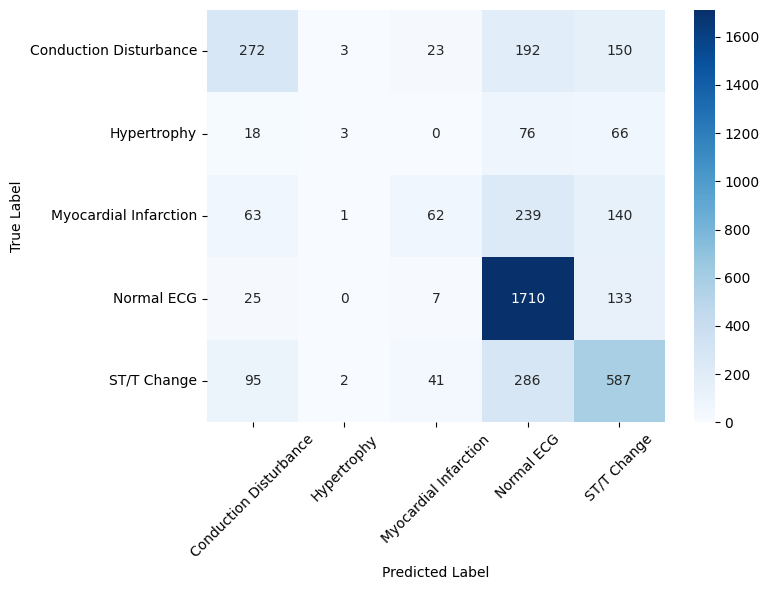

In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True, 
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

DENSE MODEL


In [19]:
X = features_df.drop(columns=["diagnosis"]).to_numpy()
y_labels = features_df["diagnosis"].to_numpy()

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X = scaler.fit_transform(X)

le = LabelEncoder()
y_int = le.fit_transform(y_labels)
y = to_categorical(y_int)



X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_int
)

print("X:", X_train.shape, "y:", y_train.shape)


X: (16776, 1872) y: (16776, 5)


In [20]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       479,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513,029 (1.96 MB)

 Trainable params: 513,029 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5967 - loss: 1.1329 - val_accuracy: 0.6736 - val_loss: 0.8957 - learning_rate: 0.0010
Epoch 2/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6643 - loss: 0.9292 - val_accuracy: 0.6898 - val_loss: 0.8604 - learning_rate: 0.0010
Epoch 3/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6890 - loss: 0.8642 - val_accuracy: 0.7000 - val_loss: 0.8325 - learning_rate: 0.0010
Epoch 4/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6985 - loss: 0.8346 - val_accuracy: 0.7031 - val_loss: 0.8183 - learning_rate: 0.0010
Epoch 5/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7098 - loss: 0.7956 - val_accuracy: 0.7024 - val_loss: 0.8082 - learning_rate: 0.0010
Epoch 6/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7175 - loss: 0.7841 - val_accuracy: 0.7060 - val_loss: 0.8038 - learning_rate: 0.0010
Epoch 7/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7253 - loss: 0.7617 - 

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_val).argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))
print(confusion_matrix(y_true, y_pred))

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                        precision    recall  f1-score   support

Conduction Disturbance       0.74      0.61      0.67       640
           Hypertrophy       0.49      0.11      0.18       163
 Myocardial Infarction       0.52      0.45      0.49       505
            Normal ECG       0.79      0.90      0.84      1875
           ST/T Change       0.67      0.70      0.69      1011

              accuracy                           0.72      4194
             macro avg       0.64      0.55      0.57      4194
          weighted avg       0.71      0.72      0.71      4194

[[ 390    2   60  101   87]
 [  21   18   14   60   50]
 [  32    0  229  136  108]
 [  35   11   52 1680   97]
 [  51    6   84  160  710]]


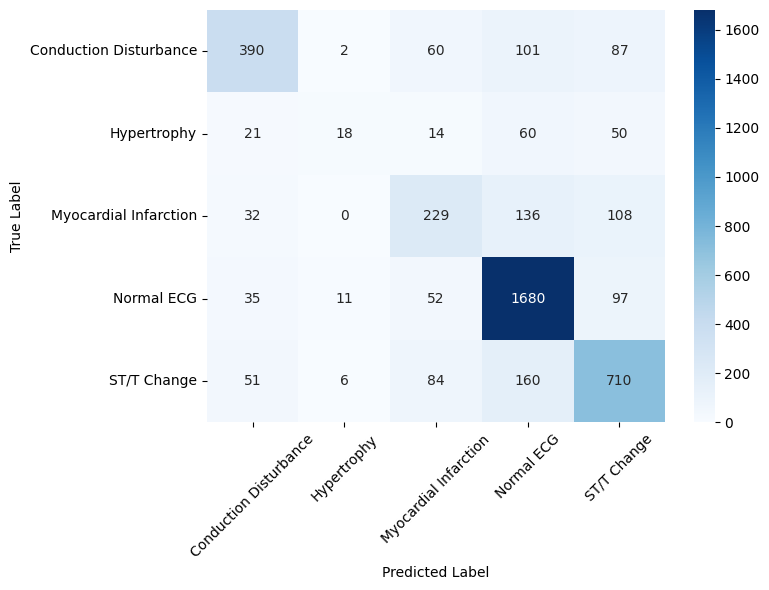

In [23]:
cm = confusion_matrix(y_true, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True, 
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

look at class imbalance

either undersample or oversample

ask izaak